In [1]:
import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u
from astropy import constants as c
from scipy.integrate import quad
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit

In [10]:
# import ROOT as r
# import warnings
# warnings.filterwarnings('ignore')

In [11]:
# r.gSystem.Load('$EVNDISPSYS/lib/libVAnaSum.so')

In [12]:
# filename = '/raid/reedbuck/lrizk/veritas/simulations/evndisp/muons/820900.root'
# sim_820900 = r.TFile(filename)
# params = sim_820900.Get('Tel_2/tpars')

In [13]:
# num_events = 0
# for event in params:
#     if event.muonValid and event.muonRadius:
#         num_events += 1

In [14]:
# sim_muon_params = np.zeros((3, num_events))
# i = 0

# for event in params:
#     if event.muonValid and event.muonRadius:
#         sim_muon_params[0][i] = event.muonRadius
#         sim_muon_params[1][i] = event.muonRSigma
#         sim_muon_params[2][i] = event.muonIPCorrectedSize
#         i += 1

In [15]:
# output = 'sim_data/muons_820900.csv'
# np.savetxt(output, sim_muon_params.T, delimiter=',')

In [8]:
sims = 'sim_data/muons_820900.csv'
muon_radii, muon_radii_err, muon_sizes = np.loadtxt(sims, delimiter=',', unpack=True)

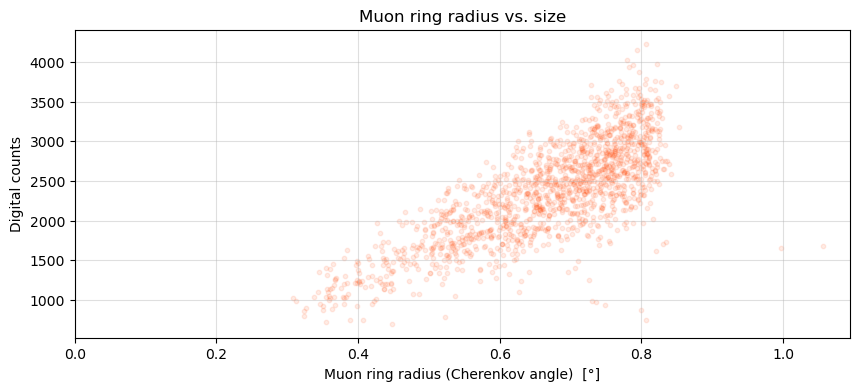

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.scatter(muon_radii, muon_sizes, c='orangered', marker='o', s=10, alpha=0.1)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Muon ring radius vs. size')

plt.xlim(xmin=0)

plt.show()

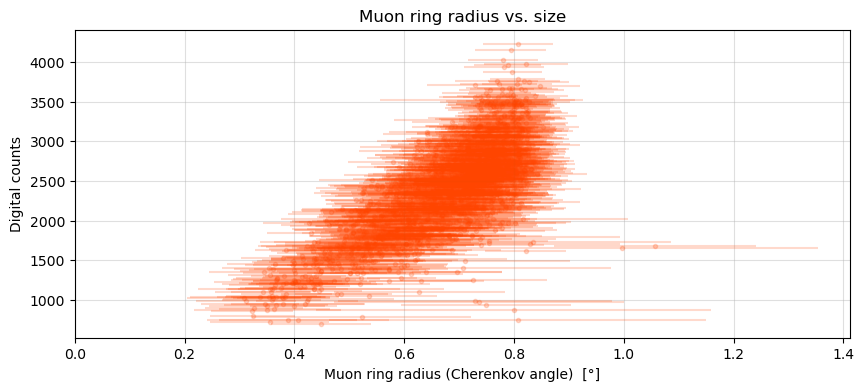

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.errorbar(x=muon_radii, xerr=muon_radii_err, y=muon_sizes,
             c='orangered', marker='o', ms=3, ls='', alpha=0.2)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Muon ring radius vs. size')

plt.xlim(xmin=0)
#plt.ylim(0, 1e4)

plt.show()

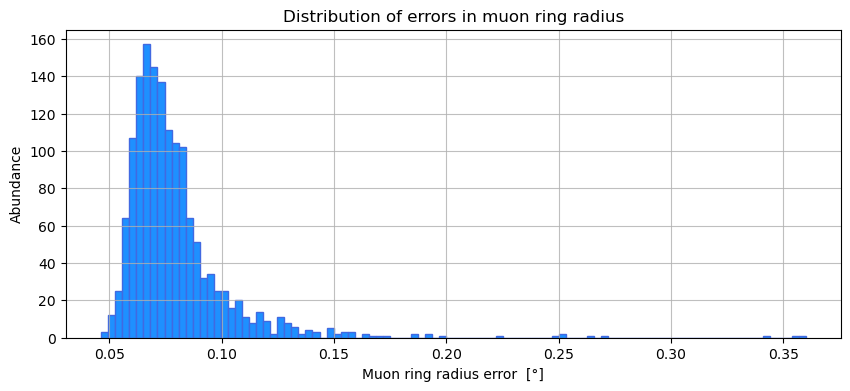

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))

hist_data = plt.hist(muon_radii_err, bins=100, edgecolor='royalblue', color='dodgerblue')

plt.grid(alpha=0.8)
plt.xlabel('Muon ring radius error  [°]')
plt.ylabel('Abundance')
plt.title('Distribution of errors in muon ring radius')

plt.show()

In [77]:
# err_cutoff = hist_data[1][9]
err_cutoff = 0.085

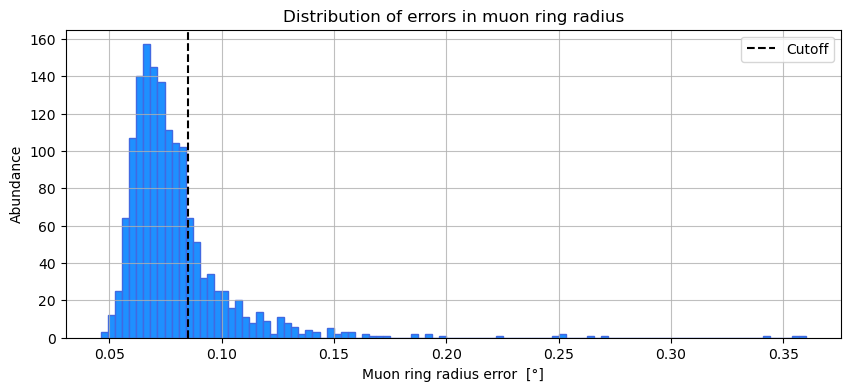

In [78]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.hist(muon_radii_err, bins=100, edgecolor='royalblue', color='dodgerblue')
plt.axvline(x=err_cutoff, c='black', ls='--', label='Cutoff')

plt.grid(alpha=0.8)
plt.xlabel('Muon ring radius error  [°]')
plt.ylabel('Abundance')
plt.title('Distribution of errors in muon ring radius')

plt.legend()
plt.show()

In [79]:
good_muon_radii = muon_radii[muon_radii_err < err_cutoff]
good_muon_radii_err = muon_radii_err[muon_radii_err < err_cutoff]
good_muon_sizes = muon_sizes[muon_radii_err < err_cutoff]

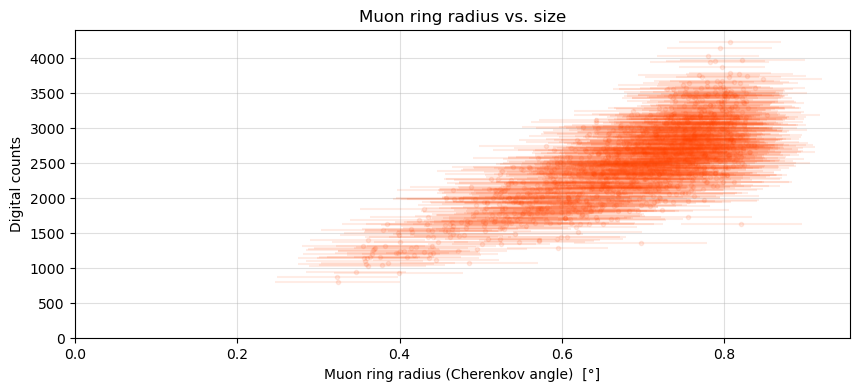

In [80]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.errorbar(x=good_muon_radii, 
             xerr=good_muon_radii_err,
             y=good_muon_sizes,
             c='orangered', marker='o', ms=3, ls='', alpha=0.1)

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Muon ring radius vs. size')

plt.xlim(xmin=0)
plt.ylim(ymin=0)

plt.show()

In [81]:
directory = 'output/'

muon_E_span = np.load(directory + 'muon_E.npy')
angles_deg = np.load(directory + 'ring_radii.npy')
true_ring_intensities = np.load(directory + 'muon_ring_sizes.npy')
true_ring_intensities_MM = np.load(directory + 'MM_ring_sizes.npy')

In [82]:
def linear(y, a, b):

    a_prime = 1/a
    b_prime = -b/a
    
    return a_prime * y + b_prime

In [83]:
def linear_0(y, a):

    a_prime = 1/a
    
    return a_prime * y

In [84]:
# theory_fit = curve_fit(
#     linear, 
#     ydata=angles_deg[angles_deg * true_ring_intensities > 0], 
#     xdata=true_ring_intensities[angles_deg * true_ring_intensities > 0], 
#     p0=[5000, 0])

theory_fit = curve_fit(
    linear, 
    ydata=angles_deg[angles_deg > 0.2], 
    xdata=true_ring_intensities[angles_deg > 0.2], 
    p0=[5000, 0])

theory_slope, theory_intercept = theory_fit[0]

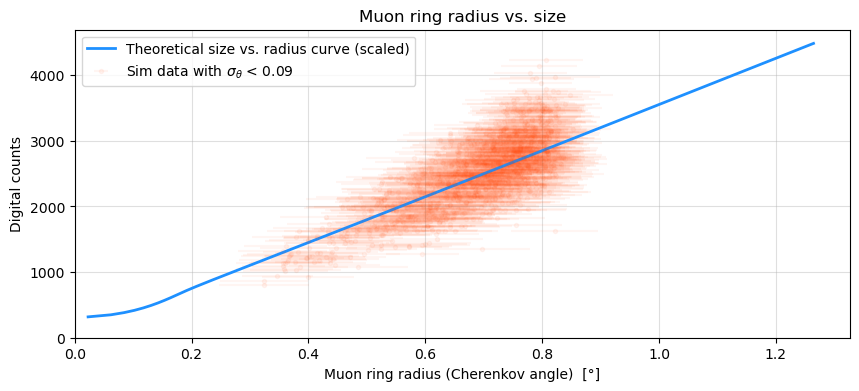

In [85]:
GAIN = 2  # (guess)

fig, ax = plt.subplots(figsize=(10, 4))

plt.errorbar(x=good_muon_radii, 
             xerr=good_muon_radii_err,
             y=good_muon_sizes,
             c='orangered', marker='o', ms=3, ls='', alpha=0.05,
             label=r'Sim data with $\sigma_\theta$ < {}'.format(round(err_cutoff, 2)))

plt.plot(angles_deg, true_ring_intensities * GAIN, c='dodgerblue', lw=2,
         label='Theoretical size vs. radius curve (scaled)')

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Muon ring radius vs. size')

plt.xlim(xmin=0)
plt.ylim(ymin=0)
# plt.ylim(0, 1e4)

plt.legend()
plt.show()

In [86]:
fit_0 = curve_fit(
    linear_0,
    xdata=good_muon_sizes, 
    ydata=good_muon_radii,
    sigma=good_muon_radii_err, 
    absolute_sigma=True, 
    p0=[5000],
)

In [87]:
slope_0 = fit_0[0][0]
print('Sim data slope:', slope_0)
print('Theory slope:', theory_slope)

Sim data slope: 3748.830694861809
Theory slope: 1757.7608151786783


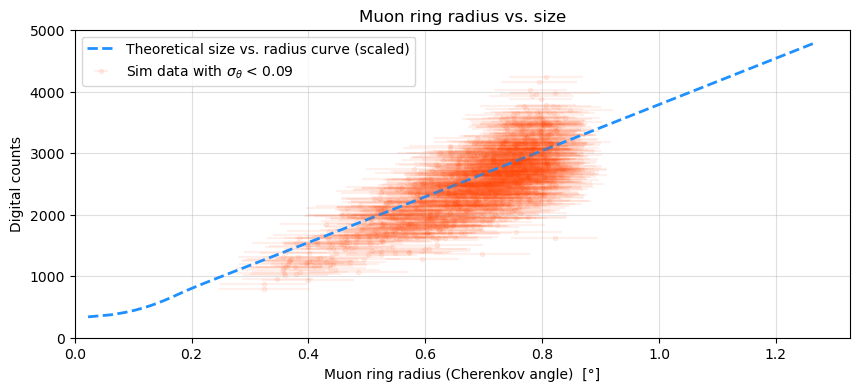

In [88]:
GAIN = slope_0 / theory_slope

angles_range = np.linspace(
    np.min(good_muon_radii) - 0.05,
    np.max(good_muon_radii) + 0.05,
    1000
) 

fig, ax = plt.subplots(figsize=(10, 4))

plt.errorbar(x=good_muon_radii, 
             xerr=good_muon_radii_err,
             y=good_muon_sizes,
             c='orangered', marker='o', ms=3, ls='', alpha=0.08,
             label=r'Sim data with $\sigma_\theta$ < {}'.format(round(err_cutoff, 2)))

# plt.plot(angles_range, slope_0 * angles_range, c='blueviolet', lw=2.5,
#          label=r'Linear fit: $N \, = \, {} \, \theta$'.format(
#              round(slope_0, 2), 
#          ))

plt.plot(angles_deg, true_ring_intensities * GAIN, c='dodgerblue', lw=2, ls='--',
         label='Theoretical size vs. radius curve (scaled)')

plt.grid(alpha=0.4)
plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Digital counts')
plt.title('Muon ring radius vs. size')

plt.xlim(xmin=0)
plt.ylim(ymin=0)
# plt.ylim(0, 1e4)

plt.legend()
plt.show()

In [89]:
# Chi2 test

model_guesses_0 = linear_0(good_muon_sizes, slope_0)

chi2 = np.sum((model_guesses_0 - good_muon_radii)**2 / (good_muon_radii_err)**2)
dof = len(model_guesses_0) - 1
red_chi2 = chi2/dof
print(red_chi2)

2.0895246765519695


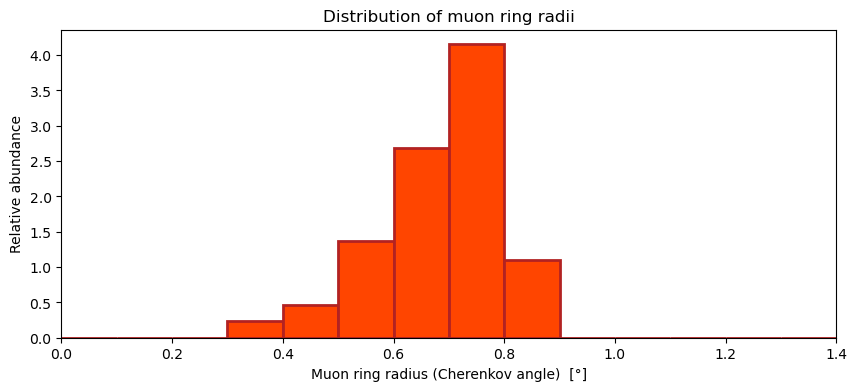

In [90]:
histobins = np.arange(0, 1.5, 0.1)

fig, ax = plt.subplots(figsize=(10, 4))

plt.hist(good_muon_radii, bins=histobins, density=True,
         edgecolor='firebrick', lw=2, color='orangered')

plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel('Relative abundance')
plt.title('Distribution of muon ring radii')

plt.xlim(histobins[0], histobins[-1])

plt.show()

In [91]:
muon_mass = (105.65837 * u.MeV/c.c**2).to(u.kg).value  # kg
veritas_alt = 1268  # m
optimal_wvl = 380*1e-9

def n_air(lam, alt=veritas_alt):

    # Empirically determined constants
    A = 2.73e-4 
    B = 1.23e-18  # m^2
    C = 3.56e-32  # m^4
    
    # Scale height of the atmosphere
    h_0 = 8.4e3  # m

    epsilon_0 = A + B/lam**2 + C/lam**4
    epsilon = epsilon_0 * np.exp(-alt / h_0)
    
    return 1 + epsilon

def get_beta(E, m=c.m_e.value):

    return np.sqrt(1 - m**2 * c.c.value**4 / E**2)

def get_cherenkov_angle(beta, n):

    return np.arccos(1 / (beta * n))

def dNdtheta(theta, N_tot, E_min, E_max, index, n, m):

    a = N_tot * (index+1) / (E_max**(index+1) - E_min**(index+1))

    A = a * (m * c.c.value**2) ** (index+1)
    B = (1 - n**-2 * np.cos(theta)**-2) ** (-0.5*index - 1.5)
    C = np.tan(theta) * n**-2 * np.cos(theta)**-2

    return A * B * C

N_tot = len(good_muon_radii)
E_min = 4.9 * u.GeV.to(u.J)  # J
E_max = 6.5 * u.GeV.to(u.J)  # J
index = -1.5

reference_n = n_air(optimal_wvl)
asymptotic_theta = get_cherenkov_angle(beta=1, n=reference_n)
sample_thetas = np.linspace(
    get_cherenkov_angle(beta=get_beta(E_min, m=muon_mass), n=reference_n),
    get_cherenkov_angle(beta=get_beta(E_max, m=muon_mass), n=reference_n),
    10000
)

In [92]:
histo_values, bin_edges = np.histogram(good_muon_radii, bins=40, density=True)

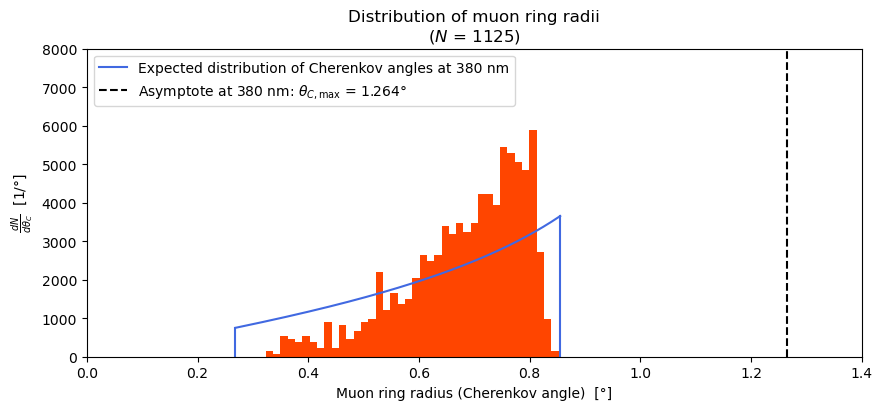

In [93]:
fig, ax = plt.subplots(figsize=(10, 4))
ymax = 8000

plt.stairs(histo_values * N_tot, bin_edges, fill=True, color='orangered')  # Area of all bins = N_tot

plt.plot(sample_thetas / np.pi * 180, 
         dNdtheta(sample_thetas, N_tot, E_min, E_max, index, n=reference_n, m=muon_mass) * np.pi / 180,
         c='royalblue', lw=1.5,
         label='Expected distribution of Cherenkov angles at {} nm'.format(int(optimal_wvl * 1e9)))

plt.axvline(sample_thetas[0] / np.pi * 180,
            ymax=dNdtheta(sample_thetas[0], N_tot, E_min, E_max, index, n=reference_n, m=muon_mass) * np.pi / 180 / ymax,
            c='royalblue', lw=1.5)

plt.axvline(sample_thetas[-1] / np.pi * 180, 
            ymax=dNdtheta(sample_thetas[-1], N_tot, E_min, E_max, index, n=reference_n, m=muon_mass) * np.pi / 180 / ymax,
            c='royalblue', lw=1.5)

plt.axvline(asymptotic_theta / np.pi * 180, 
            label='Asymptote at {} nm: '.format(int(optimal_wvl * 1e9))
            + r'$\theta_{C, \mathrm{max}}$ = ' 
            + str(round(asymptotic_theta / np.pi * 180, 3)) + '°',
            c='black', lw=1.5, ls='--')

plt.xlabel('Muon ring radius (Cherenkov angle)  [°]')
plt.ylabel(r'$\frac{dN}{d\theta_C}$  [1/°]')
plt.title('Distribution of muon ring radii\n' + r'($N$ = {})'.format(int(N_tot)))

plt.xlim(histobins[0], histobins[-1])
plt.ylim(0, ymax)

plt.legend()
plt.show()